In [1]:
import pandas as pd
import numpy as np
import xarray as xr   

import matplotlib.pyplot as plt  

from bluemath_tk.datamining.lhs import LHS
from bluemath_tk.datamining.mda import MDA

#### Latin HyperCube Sampling

In [7]:
dimensions_names = ['hs', 'hs_l0', 'swl']
lower_bounds = [0.5, 0.0005, -0.6]
upper_bounds = [1.6, 0.009, 0.356]
num_samples = 10000
lhs_object = LHS(num_dimensions=len(dimensions_names), seed=1)
lhs_df = lhs_object.generate(dimensions_names=dimensions_names, lower_bounds=lower_bounds, upper_bounds=upper_bounds, num_samples=num_samples)

#### MDA

In [8]:
n_centers=1000
mda_object = MDA(num_centers=n_centers)
data = lhs_df
mda_object.fit(data=data,first_centroid_seed=0, normalize_data=True)
mda_df = mda_object.centroids

In [9]:
mda_df['tp'] =  np.sqrt((mda_df["hs"].values * 2 * np.pi) / (9.806 * mda_df["hs_l0"]))
lhs_df['tp'] =  np.sqrt((lhs_df["hs"].values * 2 * np.pi) / (9.806 * lhs_df["hs_l0"]))

#### Outpus

In [10]:
mda_df.to_csv('outputs/mda_df.csv',index=False)
lhs_df.to_csv('outputs/lhs_df.csv',index=False)

#### Plot

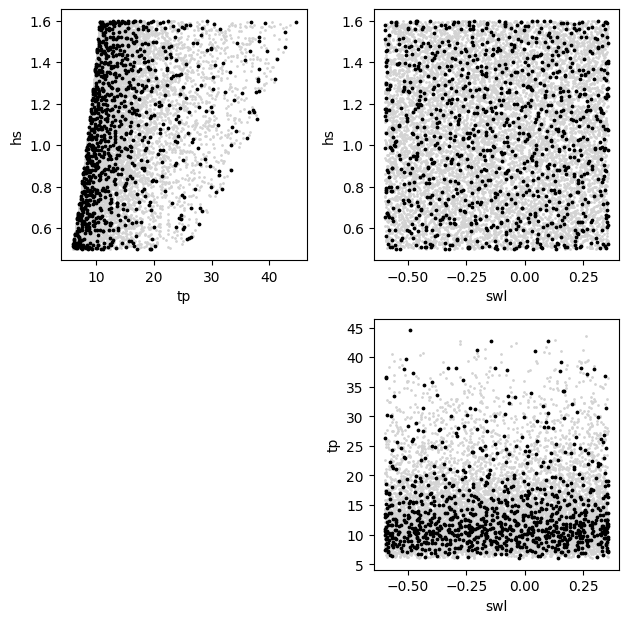

In [11]:
n_vars = len(dimensions_names)
vars_to_plot = ['hs','tp','swl']

fig, axes = plt.subplots(n_vars,n_vars,figsize=(n_vars*3,n_vars*3))

for i in range(n_vars):
    for j in range(n_vars):

        if j <= i:
            axes[i,j].set_visible(False)
        else:
            axes[i,j].scatter(lhs_df[vars_to_plot[j]],lhs_df[vars_to_plot[i]], color='lightgray',s=1)
            axes[i,j].scatter(mda_df[vars_to_plot[j]],mda_df[vars_to_plot[i]], color='k',        s=3)
            axes[i,j].set_xlabel(vars_to_plot[j])
            axes[i,j].set_ylabel(vars_to_plot[i])

plt.tight_layout()
plt.show()        


In [12]:
mda_df

,hs,hs_l0,swl,tp
0,0.983834,0.002803,0.299965,14.997440
1,1.555303,0.008363,-0.598757,10.916268
2,0.508501,0.004764,-0.570568,8.269786
3,1.593681,0.000514,-0.490663,44.579528
4,1.594630,0.008759,0.346428,10.800859
...,...,...,...,...
995,1.034261,0.000508,-0.265828,36.106114
996,1.237338,0.003483,0.188973,15.087649
997,1.400342,0.003250,0.002241,16.616252
998,1.564118,0.002089,0.271210,21.903903
